# **IS4487 Week 11 - Practice/Demo Code: Linear and Logistic Regression and K-Nearest Neighbor Models**

This notebook is designed to help you follow along with the **Week 11 Lecture and Reading**, introducing you to Regression.

The practice code demos are intended to give you a chance to see working code and can be a source for your lab and assignment work.  Each section contains short explanations and annotated code that reflect the steps in the reading.

### Topics for this demo:
- Create a linear regression to predict a numeric value
- Visualize the regression line
- Use logistic regressio to predict a binary categorical value
- Use KNN to classify for comparison with logistic regression

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_11_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Context: Apple (AAPL) Stock Price Prediction
We will use historical stock prices, in addition to two calculated metrics, to predict the stock price on the following day of trading.

Variables include:

| Feature     | Description                                          | Type        |
| ----------- | ---------------------------------------------------- | ----------- |
|`Date`        |The date trading prices are measured          |Date    |
| `Open`       | Beginning stock price on the given day                                  | Numeric     |
| `High`       | Maximum stock price on the given day     | Numeric |
| `Low`   | Minimum  stock price on the given day              | Numeric |
| `Close` | Closing stock price on the given day | Numeric |
| `Volume`   |  Number of shared traded on the given day                           | Numeric |
| `Direction`   | Comparison of tomorrow's close to today's open price                         | Categorical |
| `RSI`      | Relative Strength Index.  RSI compares the average gains to the average losses in the last 14 trading days                        | Numeric |
| `SMA_5`   | 5-period Simple Moving Average     | Numeric     |
| `Next_Day_Closing`   | Closing stock price on the next trading day         | Numeric |

Your task is to predict `Next_Day_Closing`,  the stock price on the following day of trading.

#**ML model: Linear Regression**

We will first build a linear regression model to predict y = `Next_Day_Closing`, using X = features in the dataset, and then compare the prediction to the actual values in a plot.

## **Step 1. Import libraries, load data and preview it**

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Load the dataset
url = "https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/aapl_stock_prices.csv"
df = pd.read_csv(url, sep=',')

In [46]:
#Preview the data
df.head(n=10)

,Date,Open,High,Low,Close,Volume,SMA_5,RSI,Direction,Next_Day_Closing
0,1/1/2024,190.08,191.26,189.10,190.14,53020510,NaN,NaN,Down,189.86
1,1/2/2024,190.08,190.42,189.48,189.86,42711634,NaN,NaN,Up,191.44
2,1/3/2024,191.38,192.61,190.57,191.44,50797566,NaN,NaN,Up,193.11
3,1/4/2024,192.83,194.31,191.40,193.11,37414802,NaN,NaN,Down,192.31
4,1/5/2024,192.28,193.29,191.39,192.31,51593301,191.37,NaN,Down,192.14
5,1/8/2024,192.12,193.86,191.30,192.14,35443031,191.77,NaN,Up,193.93
6,1/9/2024,194.28,194.69,194.16,193.93,51053323,192.59,NaN,Down,193.78
7,1/10/2024,194.11,194.29,192.94,193.78,50663645,193.05,NaN,Down,193.51
8,1/11/2024,194.21,194.30,193.09,193.51,54567589,193.13,NaN,Up,195.25
9,1/12/2024,194.38,195.93,192.50,195.25,42061183,193.72,NaN,Down,193.29


In [47]:
# check number of missing values
print(df.info())

# check distributions of numeric variables
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              300 non-null    object 
 1   Open              300 non-null    float64
 2   High              300 non-null    float64
 3   Low               300 non-null    float64
 4   Close             300 non-null    float64
 5   Volume            300 non-null    int64  
 6   SMA_5             296 non-null    float64
 7   RSI               287 non-null    float64
 8   Direction         300 non-null    object 
 9   Next_Day_Closing  299 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 23.6+ KB
None


,Open,High,Low,Close,Volume,SMA_5,RSI,Next_Day_Closing
count,300.000000,300.000000,300.000000,300.000000,3.000000e+02,296.000000,287.000000,299.000000
mean,184.014900,184.869400,183.142800,184.061000,4.505795e+07,183.989797,48.101045,184.040669
std,4.570362,4.643264,4.575252,4.656482,5.625189e+06,4.524086,12.991411,4.650932
min,176.250000,176.270000,174.630000,175.690000,3.501968e+07,176.920000,11.110000,175.690000
25%,179.957500,180.937500,179.195000,179.925000,4.048629e+07,179.975000,40.170000,179.920000
50%,183.715000,184.230000,182.890000,183.720000,4.512861e+07,183.330000,48.870000,183.700000
75%,187.600000,188.647500,186.785000,187.680000,5.015548e+07,187.550000,56.935000,187.660000
max,194.380000,195.930000,194.160000,195.250000,5.472408e+07,193.950000,79.570000,195.250000


## **Step 2: Prepare Data**

We will create a set of features as a list [], and also set the target variable. Then drop the rows that have any missing vales. You can also choose to fill or impute them. Finally, create X (set of features) and y (target) with no missing values.
If needed, you can also change data types. for example, the date column is read as an objec (text string).

In [48]:
# Select features and target for stock price prediction
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_5', 'RSI']
target = 'Next_Day_Closing'

# Drop rows with missing values in selected features or target
df_cleaned = df.dropna(subset=features + [target])

# Define features (X) and target (y)
X = df_cleaned[features]
y = df_cleaned[target]



## **Step 3: Split Dataset into Training and Testing**

In [49]:
# Split the data into training and testing sets for X and y - select 20% as testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (228, 7)
X_test shape: (58, 7)
y_train shape: (228,)
y_test shape: (58,)


## **Step 4: Create and Fit Model**

In [50]:
# Create and train Linear Regression model
model_linreg = LinearRegression()
model_linreg.fit(X_train, y_train)



LinearRegression()

##**Step 5: Make Predictions and Evaluate Model**

We will chekc the performance of the model first in the training data.

To evaluate the model, only the performance of testing data matters.

But the training data performance can give us a clue into whether the model if overfitting or underfitting. Recall,
Overfitting : training error low, testing error high
Underfitting : training error high, testing error high
Good fit: both errors are reasonably low

In [51]:
#### TRAINING DATA PERFORMANCE #####
# Predict
y_train_pred = model_linreg.predict(X_train)

# Evaluate
r2 = r2_score(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = root_mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)

print(f"Training R² score: {r2:.2f}")
print(f"Training Mean Squared Error: {mse:.2f}")
print(f"Training Root Mean Squared Error: {rmse:.2f}")
print(f"Training Mean Absolute Error: {mae:.2f}")


#### MODEL EVALUATION - TESTING DATA PERFORMANCE #####
# Predict
y_pred = model_linreg.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n\nTesting R² score: {r2:.2f}")
print(f"Testing Mean Squared Error: {mse:.2f}")
print(f"Testing Root Mean Squared Error: {rmse:.2f}")
print(f"Testing Mean Absolute Error: {mae:.2f}")

Training R² score: 0.92
Training Mean Squared Error: 1.55
Training Root Mean Squared Error: 1.25
Training Mean Absolute Error: 0.98


Testing R² score: 0.90
Testing Mean Squared Error: 1.54
Testing Root Mean Squared Error: 1.24
Testing Mean Absolute Error: 1.00


**Interpretation of results**

The model gives good results (reasonably high R^2 and low MSE/RMSE/MAE).
R^2 is easier to understand since the max value is 100%, so 90% in testing is really good.

MSE is harder to know if its big or small. So we compute RMSE - which has the same units as the target, and compare that to the mean value of the target.
RMSE in test data is 1.24 compared to the mean of y = `Next_day_closing` = 184 (obtained from .describe() above). This is not bad at all, an average error of 1.24 units is acceptable compared to mean of 184.

Similarly, MAE , which is also in the same units as target is 1.0, (out of mean next day closing price of 184) - so not bad at all, and is an acceptable amount of error.


## **Step 6: Create Visualization**

Let us plot the predicted vs actual data points for y = next day closing stock price. Points along the red line are predicted accurately. Points above the line have a positive error and points below have a negative error.

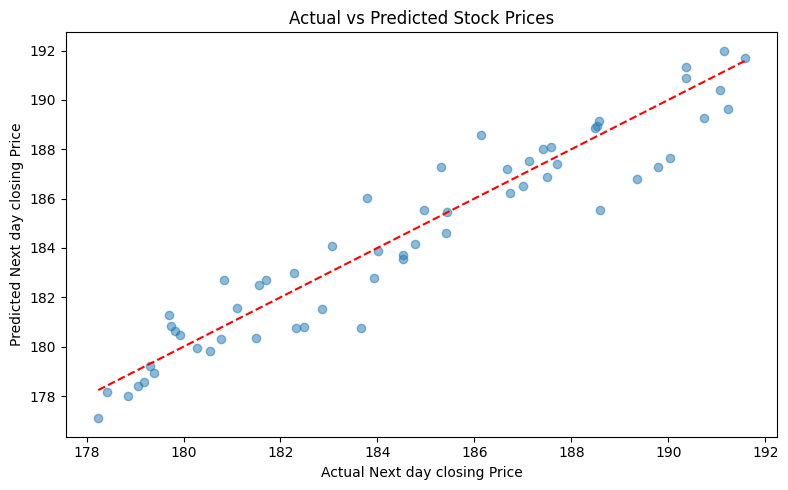

In [52]:
# Plot actual vs predicted next day closing stock prices
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Next day closing Price')
plt.ylabel('Predicted Next day closing Price')
plt.title('Actual vs Predicted Stock Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.tight_layout()
plt.show()

Generally, linear models are affected by outlier, so its a good idea to deal with them before running regression.

# **ML model: Logistic Regression**

let us use the same dataset to predict a categorical outcome - `Direction`. This is stored as object, we will need to convert this into a 0/1 variable in order to use it in predictive modeling.
This will become our outcome `y`, and since this is a binary outcome, we will use Logistic Regression to predict y from the features X.


## **Step 7: Prepare the data - fix datatypes and add new features**

We will fix the datatypes of Direction, create a new variable to indicate the binary outcome.

We will also change the datatype of Date column - we will not use date directly in our analysis, but we will extract month and dayofweek from the Date variable (we can do that once it is set as type datetime.)

In [53]:
# Change Direction's datatype to category, and create a new column to convert Direction into 0, 1
df['Direction'] = df['Direction'].astype('category')
df['Dir_Up'] = df['Direction'].map({'Up':1, 'Down': 0})

df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce')

# Feature engineering
# add three new date-related features
df['DayofWeek'] = df['Date'].dt.dayofweek   #Monday is 0 and Sunday is 6
df['Month'] = df['Date'].dt.month
df['Year_2024'] = df['Date'].dt.year.map({2024:1, 2025:0})

# One-hot encode 'DayofWeek' - one column DayofWeek_0 = Monday will be dropped
df_encoded = pd.get_dummies(df, columns=['DayofWeek'], drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns=['Month'], drop_first=True)

# view the changes
display(df_encoded.describe())
display(df_encoded.head())

# view the counts of each
display(df_encoded['Dir_Up'].value_counts())

,Date,Open,High,Low,Close,Volume,SMA_5,RSI,Next_Day_Closing,Year_2024
count,300,300.000000,300.000000,300.000000,300.000000,3.000000e+02,296.000000,287.000000,299.000000,300.000000
mean,2024-07-27 12:00:00,184.014900,184.869400,183.142800,184.061000,4.505795e+07,183.989797,48.101045,184.040669,0.873333
min,2024-01-01 00:00:00,176.250000,176.270000,174.630000,175.690000,3.501968e+07,176.920000,11.110000,175.690000,0.000000
25%,2024-04-14 06:00:00,179.957500,180.937500,179.195000,179.925000,4.048629e+07,179.975000,40.170000,179.920000,1.000000
50%,2024-07-27 12:00:00,183.715000,184.230000,182.890000,183.720000,4.512861e+07,183.330000,48.870000,183.700000,1.000000
75%,2024-11-08 18:00:00,187.600000,188.647500,186.785000,187.680000,5.015548e+07,187.550000,56.935000,187.660000,1.000000
max,2025-02-21 00:00:00,194.380000,195.930000,194.160000,195.250000,5.472408e+07,193.950000,79.570000,195.250000,1.000000
std,NaN,4.570362,4.643264,4.575252,4.656482,5.625189e+06,4.524086,12.991411,4.650932,0.333155


,Date,Open,High,Low,Close,Volume,SMA_5,RSI,Direction,Next_Day_Closing,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,2024-01-01,190.08,191.26,189.10,190.14,53020510,NaN,NaN,Down,189.86,...,False,False,False,False,False,False,False,False,False,False
1,2024-01-02,190.08,190.42,189.48,189.86,42711634,NaN,NaN,Up,191.44,...,False,False,False,False,False,False,False,False,False,False
2,2024-01-03,191.38,192.61,190.57,191.44,50797566,NaN,NaN,Up,193.11,...,False,False,False,False,False,False,False,False,False,False
3,2024-01-04,192.83,194.31,191.40,193.11,37414802,NaN,NaN,Down,192.31,...,False,False,False,False,False,False,False,False,False,False
4,2024-01-05,192.28,193.29,191.39,192.31,51593301,191.37,NaN,Down,192.14,...,False,False,False,False,False,False,False,False,False,False


,count
Dir_Up,
0,150
1,150


 The day of week indicates Monday as 0 and Sunday as 6. We see the min is 0 (Monday) and max is 4 (Friday) as expected.

 The months run from Jan to Dec and Dates goes from Jan 1, 2024 to Feb 21, 2025.

 The output variable or target Dir_01 appears balanced. This may not always be the case, and if it were imbalanced, we should be careful with our evaluation of the model. Accuracy would be misleading.

## **Step 8: Select features and target, and remove rows with missing values**


In [54]:
# Select features and target for stock price prediction
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_5', 'RSI', 'DayofWeek_1',
            'DayofWeek_2', 'DayofWeek_3', 'DayofWeek_4', 'Month_2', 'Month_3',
            'Month_4','Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Year_2024']
target = 'Dir_Up'

# Drop rows with missing values in selected features or target
df_cleaned = df_encoded.dropna(subset=features + [target])

# Define features (X) and target (y)
X_large = df_cleaned[features]
y_classif = df_cleaned[target]


## **Step 9: Split the data into train-test**

In [55]:
# Split the data into training and testing sets for X and y - select 20% as testing
X_large_train, X_large_test, y_classif_train, y_classif_test = train_test_split(X_large, y_classif, test_size=0.2, random_state=44)

# Display the shapes of the resulting datasets
print("X_train shape:", X_large_train.shape)
print("X_test shape:", X_large_test.shape)
print("y_train shape:", y_classif_train.shape)
print("y_test shape:", y_classif_test.shape)

X_train shape: (229, 23)
X_test shape: (58, 23)
y_train shape: (229,)
y_test shape: (58,)


## **Step 10: Train the model**

In [88]:
# Create and train Linear Regression model
model_logreg = LogisticRegression()
model_logreg.fit(X_large_train, y_classif_train)


LogisticRegression()

## **Step 11: Evaluate the model**



 Test data Confusion Matrix:


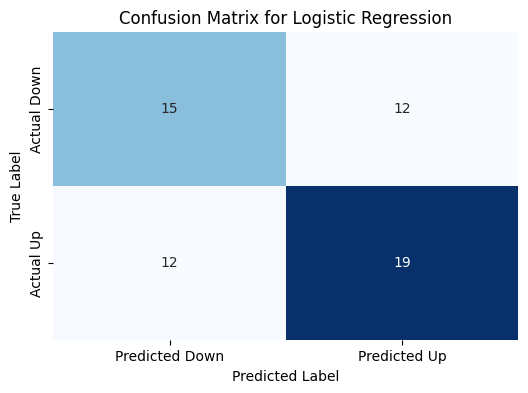



How did the model do on the test data? MODEL EVALUATION
Accuracy: 0.59
Precision: 0.61
Recall: 0.61
F1-score: 0.61


In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#### MODEL EVALUATION - TESTING DATA PERFORMANCE #####
# Predict
y_classif_pred = model_logreg.predict(X_large_test)

# Generate the confusion matrix for the test data
conf_matrix = confusion_matrix(y_classif_test, y_classif_pred)

# Draw a pretty confusion matrix
print("\n\n Test data Confusion Matrix:")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# Evaluate
accuracy = accuracy_score(y_classif_test, y_classif_pred)
precision = precision_score(y_classif_test, y_classif_pred)
recall = recall_score(y_classif_test, y_classif_pred)
f1 = f1_score(y_classif_test, y_classif_pred)

print("\n\nHow did the model do on the test data? MODEL EVALUATION")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

The confusion matrix shows:

    True Negatives (top-left): The number of instances correctly predicted as the negative class.
    False Positives (top-right): The number of instances incorrectly predicted as the positive class (Type I error).
    False Negatives (bottom-left): The number of instances incorrectly predicted as the negative class (Type II error).
    True Positives (bottom-right): The number of instances correctly predicted as the positive class.

**Draw AUC Area Under curve**

The curve is not very good indiatcing that even with all the added features, we are not able to make a good prediction of Direction of the stock price.

With an accuracy of 59% and F1 score of 61%, I woudl say our classification model is not very effective at predicting `Direction`.

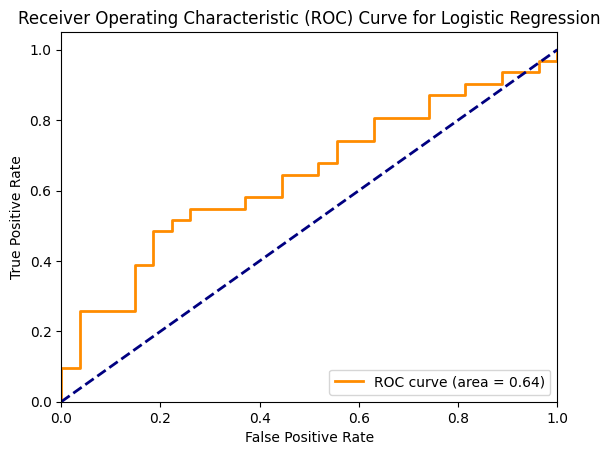

In [83]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the positive class
y_prob_logreg = model_logreg.predict_proba(X_large_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_classif_test, y_prob_logreg)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend(loc="lower right")
plt.show()

# **ML model: KNN**

KNN can be used for classification and regression.
In order to compare the model between KNN and logistic regression, we will use the same training-testing split for the data.
For KNN classificatiuon, we will use `X_large`, the large set of predictors and `y_classif`, the target variabe `Direction` that we used for logistic regression.

##**Step 12: Estimate and evaluate a Classification model using KNN**

In [81]:
# Create and train KNN model with n_neighbors=5 (you can adjust this)
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_large_train, y_classif_train)

KNeighborsClassifier()

In [82]:
# Predict on the test data
y_pred_knn = model_knn.predict(X_large_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_classif_test, y_pred_knn)
precision_knn = precision_score(y_classif_test, y_pred_knn)
recall_knn = recall_score(y_classif_test, y_pred_knn)
f1_knn = f1_score(y_classif_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_classif_test, y_pred_knn)


print("KNN Model Evaluation on Test Data:")
print(f"Accuracy: {accuracy_knn:.2f}")
print(f"Precision: {precision_knn:.2f}")
print(f"Recall: {recall_knn:.2f}")
print(f"F1-score: {f1_knn:.2f}")

print("\nTest data Confusion Matrix (KNN):")
display(conf_matrix_knn)

KNN Model Evaluation on Test Data:
Accuracy: 0.43
Precision: 0.46
Recall: 0.35
F1-score: 0.40

Test data Confusion Matrix (KNN):


array([[14, 13],
       [20, 11]])

In this example, KNN classifier with K=5 using the same predictors (X_large) as logistic regression perfomed much more poorly on the test data.
F1 score for logistic regression on test data was 0.61, whereas it is only 0.40 for KNNClassifier.

Overall, in this dataset, we were able to predict the actual closing price using regression much better than we wee able to predict wherger the next day closing price would go up or down (relatve to today's opening price).

This means we need better variables/features to predict Direction Up/Down.